In [1]:
import os
import sys

PROJECT_DIR = os.path.dirname(os.getcwd())

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

In [2]:
import matplotlib.pyplot as plt
import numpy as np


from collections import Counter
from srcs.datasets.utils import is_analysable_label, to_text
from srcs.datasets.vicocktail import load_vicocktail

MAX_FRAMES = 200
FPS = 25

d:\projects\VietnameseVSR\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_vicocktail(
    split="all",
    seed=42,
    fraction=1.0,
    val_size=0.1,
    apply_filter=False,
)

for split, split_dataset in dataset.items():
    print(f"{split:>5}: {len(split_dataset):,}")

train: 174,665
  val: 19,408
 test: 1,167


In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'length', 'sample_id', 'video', 'video_length'],
        num_rows: 174665
    })
    val: Dataset({
        features: ['label', 'length', 'sample_id', 'video', 'video_length'],
        num_rows: 19408
    })
    test: Dataset({
        features: ['label', 'length', 'sample_id', 'video', 'video_length'],
        num_rows: 1167
    })
})

In [5]:
total_frames = []

for value in dataset['train']['video_length']:
    total_frames.append(value)
    
for value in dataset['val']['video_length']:
    total_frames.append(value)
    
for value in dataset['test']['video_length']:
    total_frames.append(value)

In [6]:
frames_counter = Counter(total_frames)
sorted_counts = sorted(frames_counter.items())
lengths = [length for length, _ in sorted_counts]
counts = [count for _, count in sorted_counts]

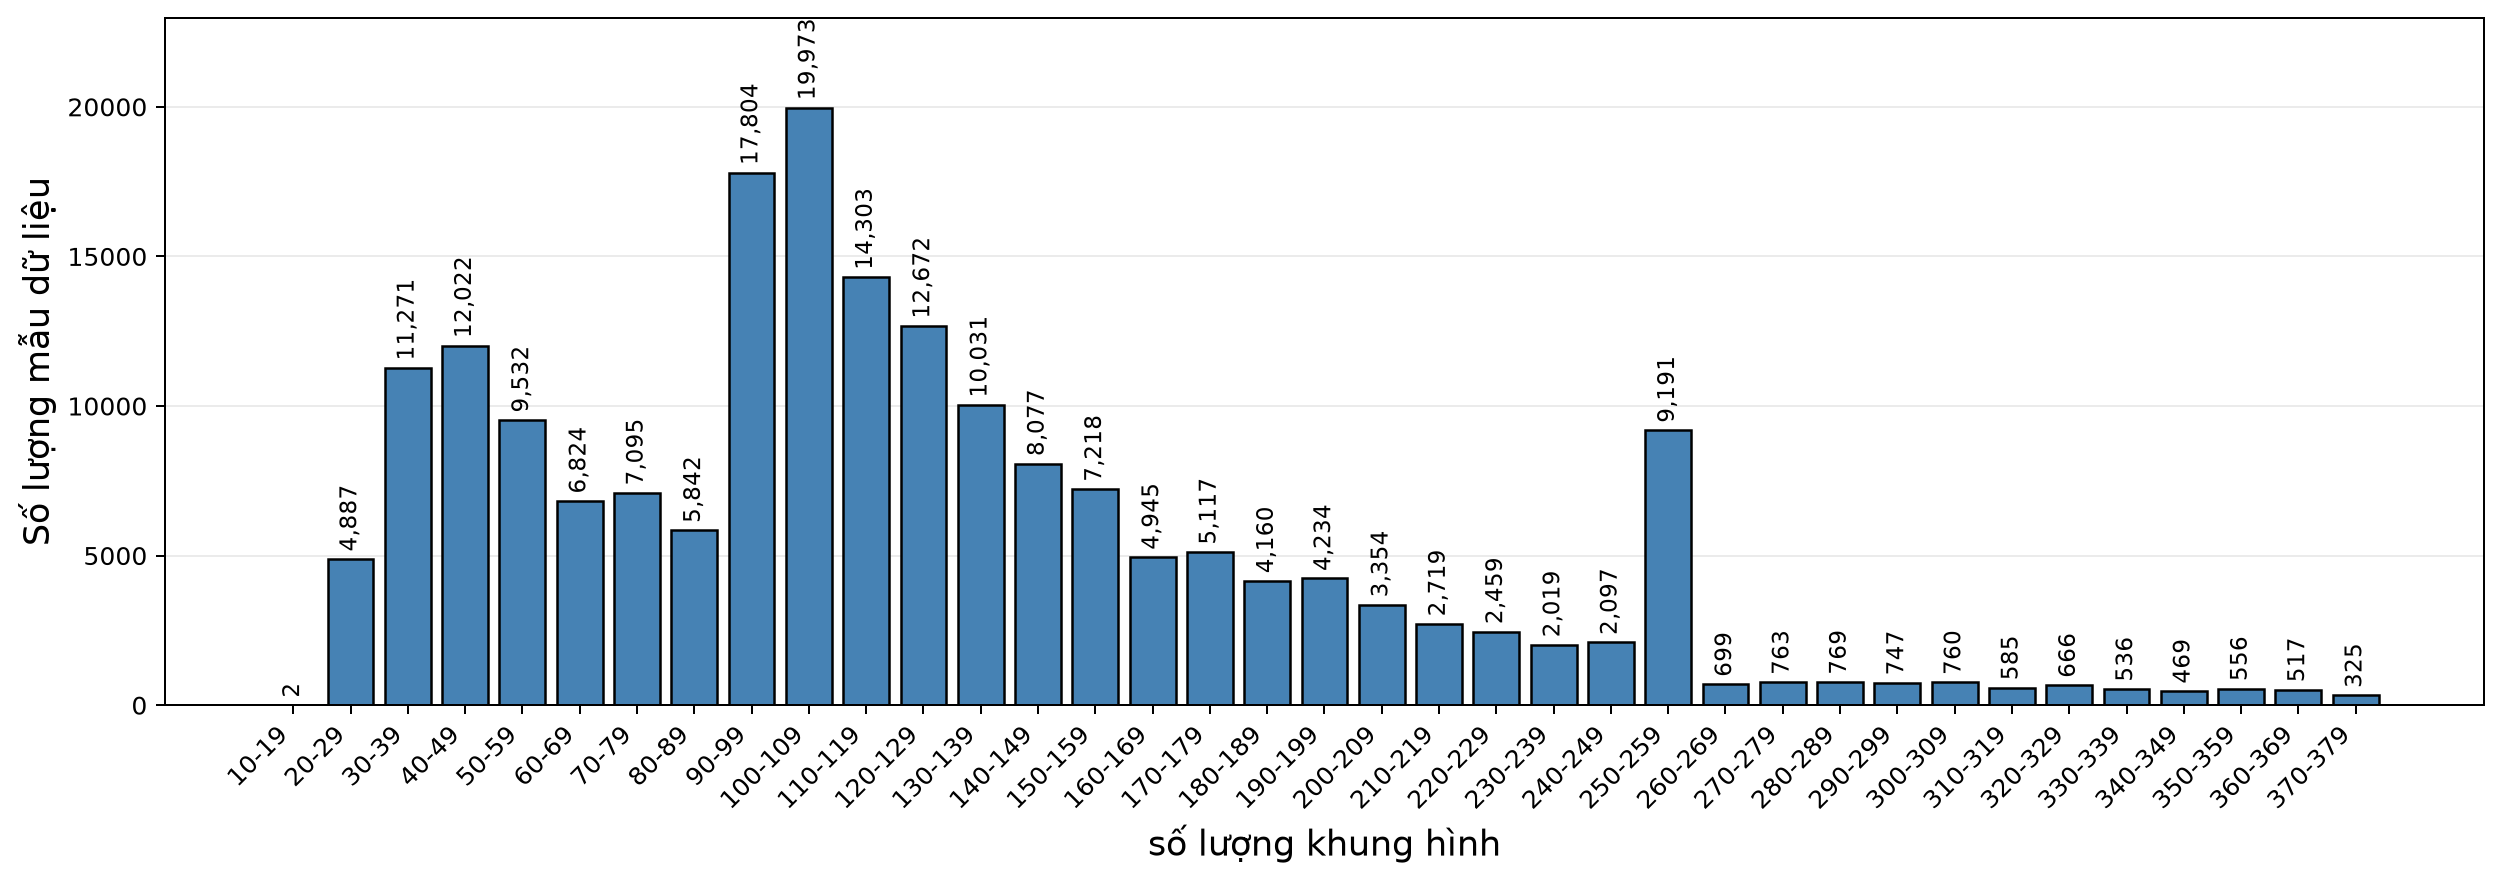

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

BIN_SIZE = 10
binned_counts = Counter()

for length, count in zip(lengths, counts):
    bin_start = (length // BIN_SIZE) * BIN_SIZE
    binned_counts[bin_start] += count

bin_starts = sorted(binned_counts)
bin_counts = [binned_counts[start] for start in bin_starts]
bin_labels = [
    f"{start}-{start + BIN_SIZE - 1}"
    for start in bin_starts
]

fig, ax = plt.subplots(figsize=(14, 5), dpi=180)

bars = ax.bar(
    range(len(bin_starts)),
    bin_counts,
    color="steelblue",
    edgecolor="black",
)

ax.bar_label(
    bars,
    labels=[f"{count:,}" for count in bin_counts],
    padding=3,
    fontsize=9,
    rotation=90,
)

ax.set_xticks(range(len(bin_starts)))
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

ax.set_xlabel("Khung hình", fontsize=14)
ax.set_ylabel("Số lượng mẫu dữ liệu", fontsize=14)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

In [12]:
import random
from collections import Counter

from torchcodec.decoders import VideoDecoder

NUM_SAMPLES = 100
RANDOM_SEED = 42

train_dataset = dataset["train"]
random_generator = random.Random(RANDOM_SEED)

sample_indices = random_generator.sample(
    range(len(train_dataset)),
    min(NUM_SAMPLES, len(train_dataset)),
)

results = []

for index in sample_indices:
    sample = train_dataset[index]
    video_source = sample["video"]

    if isinstance(video_source, dict):
        source = video_source.get("bytes")

        if source is None:
            source = video_source.get("path")
    else:
        source = video_source

    decoder = VideoDecoder(
        source,
        dimension_order="NCHW",
        num_ffmpeg_threads=2,
    )

    metadata = decoder.metadata

    start_time = float(sample.get("start_time", 0.0))
    end_time = sample.get("end_time")

    if end_time is None:
        end_time = float(metadata.duration_seconds)
    else:
        end_time = float(end_time)

    frames = decoder.get_frames_played_in_range(
        start_time,
        end_time,
    ).data

    decoded_frames = frames.size(0)
    dataset_frames = int(sample["length"])
    fps = float(metadata.average_fps)
    segment_duration = end_time - start_time

    results.append(
        {
            "index": index,
            "fps": fps,
            "decoded_frames": decoded_frames,
            "dataset_frames": dataset_frames,
            "duration": segment_duration,
            "difference": decoded_frames - dataset_frames,
        }
    )

for result in results:
    print(
        f"Index={result['index']:6d} | "
        f"FPS={result['fps']:6.2f} | "
        f"Decoded frames={result['decoded_frames']:4d} | "
        f"Dataset frames={result['dataset_frames']:4d} | "
        f"Duration={result['duration']:6.2f}s | "
        f"Difference={result['difference']:+d}"
    )

fps_counts = Counter(round(result["fps"], 2) for result in results)

print("\nFPS distribution:")

for fps, count in sorted(fps_counts.items()):
    print(f"  {fps:.2f} FPS: {count} samples")

Index=167621 | FPS= 25.00 | Decoded frames= 122 | Dataset frames= 126 | Duration=  4.88s | Difference=-4
Index= 29184 | FPS= 25.00 | Decoded frames= 158 | Dataset frames= 152 | Duration=  6.32s | Difference=+6
Index=  6556 | FPS= 25.00 | Decoded frames=  32 | Dataset frames=  32 | Duration=  1.28s | Difference=+0
Index= 72097 | FPS= 25.00 | Decoded frames=  39 | Dataset frames=  40 | Duration=  1.56s | Difference=-1
Index= 64196 | FPS= 25.00 | Decoded frames=  63 | Dataset frames=  64 | Duration=  2.52s | Difference=-1
Index= 58513 | FPS= 25.00 | Decoded frames=  18 | Dataset frames=  27 | Duration=  0.72s | Difference=-9
Index= 36579 | FPS= 25.00 | Decoded frames= 110 | Dataset frames= 104 | Duration=  4.40s | Difference=+6
Index= 26868 | FPS= 25.00 | Decoded frames=  50 | Dataset frames=  51 | Duration=  2.00s | Difference=-1
Index=142964 | FPS= 25.00 | Decoded frames=  65 | Dataset frames=  65 | Duration=  2.60s | Difference=+0
Index= 22790 | FPS= 25.00 | Decoded frames=  99 | Datas